## Reorganización de características

In [1]:
import numpy as np
import pandas as pd
import os
import pickle

In [2]:
path_features = 'DATA/features'
path_metadata = 'DATA/metadata.npz'

dic_metadata = np.load(os.path.join('DATA','metadata_filtrada.npz'), allow_pickle=True)['data'].item()


In [ ]:
dic_features = {}


for pkl in os.listdir(path_features):
    if pkl[-3:] == 'pkl':
        path_pkl = os.path.join(path_features,pkl)
        with open(path_pkl, 'rb') as f:
            dic_pkl = pickle.load(f)
    if len(dic_pkl['ids']) != 99:
        for key in dic_pkl.keys():
            if key in dic_features:
                dic_features[key] += dic_pkl[key]
            else:
                dic_features[key] = dic_pkl[key]
    else:
        print(pkl)
    
np.savez('DATA/features',data = dic_features, allow_pickle=True)

14.pkl


In [47]:
path_features_nosum = 'DATA/features_nosum'

dic_features_nosum = {}
for pkl in os.listdir(path_features_nosum):
    if pkl[-3:] == 'pkl':
        path_pkl = os.path.join(path_features_nosum,pkl)
        with open(path_pkl, 'rb') as f:
            dic_pkl = pickle.load(f)
    if len(dic_pkl['ids']) != 99:
        for key in dic_pkl.keys():
            if key in dic_features_nosum:
                dic_features_nosum[key] += dic_pkl[key]
            else:
                dic_features_nosum[key] = dic_pkl[key]
    

np.savez('DATA/features_nosum',data = dic_features_nosum, allow_pickle=True)


In [48]:
merge_dic = {'ids':[]}

for key in dic_features.keys():
    if key == 'ids':continue
    new_key = f'A__{key}'
    merge_dic[new_key] = []

for key in dic_features_nosum.keys():
    if key == 'ids':continue
    new_key = f'B__{key}'
    merge_dic[new_key] = []

In [50]:
for i,id in enumerate(dic_features['ids']):
    if id not in merge_dic['ids']:
        j = dic_features_nosum['ids'].index(id)

        for key in dic_features.keys():
            if key != 'ids':
                new_key = f'A__{key}'
                merge_dic[new_key].append(dic_features[key][i])
        
        for key in dic_features_nosum.keys():
            if key != 'ids':
                new_key = f'B__{key}'
                merge_dic[new_key].append(dic_features_nosum[key][j])
        
        merge_dic['ids'].append(id)
    

In [51]:
df_merge = pd.DataFrame(merge_dic)
np.savez('DATA/features_merge',data = merge_dic, allow_pickle=True)

# Clasificación

## Librerías

In [1]:
from sklearn.feature_selection import VarianceThreshold, SelectFromModel,RFECV
from sklearn.preprocessing import LabelEncoder,StandardScaler # Normalización
from sklearn.utils.class_weight import compute_sample_weight,compute_class_weight
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, recall_score, balanced_accuracy_score, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, roc_auc_score
from sklearn.metrics import classification_report

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE #OverSampling
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from collections import Counter
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore
import shap
import random
from collections import Counter

In [2]:
def rename_feature(name):
    parts = name.split('__')
    if len(parts) != 4:
        return name
    
    config = parts[0]        # A o B
    nivel = parts[1]         # 1, 2, 3
    segmento = parts[2]      # índice del segmento
    descriptor = parts[3]    # nombre del descriptor
    
    # Identificar método
    met = descriptor.split('_')[0]
    if met in ['sum', 'ent', 'var']:
        metodo = 'REN'
    elif met in ['H0', 'H1']:
        metodo = 'TDA'
    else:
        metodo = 'DFA'
    
    # Identificar segmentación en español
    niveles = {'1': 'Global', '2': '2x2', '3': '3x3'}
    nivel_str = niveles.get(nivel, nivel)
    
    # Traducir descriptores
    descriptores_es = {
        # MF-DFA
        'a_max':   'α_max',
        'a_min':   'α_min',
        'dif_a':   'Δα',
        'a_star':  'α*',
        'dif_L':   'ΔL',
        'dif_R':   'ΔR',
        'asy_i':   'Asimetría',
        'f_max':   'f_max',
        'f_min':   'f_min',
        'dif_f':   'Δf',
        'a':       'τ-a',
        'b':       'τ-b',
        'c':       'τ-c',
        'Hurst':   'Hurst',
        # Rényi
        # 'sum_a_max':   'Sum-α_max',
        # 'sum_a_min':   'Sum-α_min',
        # 'sum_dif_a':   'Sum-Δα',
        # 'sum_a_star':  'Sum-α*',
        # 'sum_dif_L':   'Sum-ΔL',
        # 'sum_dif_R':   'Sum-ΔR',
        # 'sum_asy_i':   'Sum-Asimetría',
        # 'sum_f_max':   'Sum-f_max',
        # 'sum_f_min':   'Sum-f_min',
        # 'sum_dif_f':   'Sum-Δf',
        # 'sum_D0':      'Sum-D0',
        # 'sum_D1':      'Sum-D1',
        # 'sum_D2':      'Sum-D2',

        'sum_a_max':   'α_max',
        'sum_a_min':   'α_min',
        'sum_dif_a':   'Δα',
        'sum_a_star':  'α*',
        'sum_dif_L':   'ΔL',
        'sum_dif_R':   'ΔR',
        'sum_asy_i':   'Asimetría',
        'sum_f_max':   'f_max',
        'sum_f_min':   'f_min',
        'sum_dif_f':   'Δf',
        'sum_D0':      'D0',
        'sum_D1':      'D1',
        'sum_D2':      'D2',

        'var_a_max':   'Var-α_max',
        'var_a_min':   'Var-α_min',
        'var_dif_a':   'Var-Δα',
        'var_a_star':  'Var-α*',
        'var_dif_L':   'Var-ΔL',
        'var_dif_R':   'Var-ΔR',
        'var_asy_i':   'Var-Asimetría',
        'var_f_max':   'Var-f_max',
        'var_f_min':   'Var-f_min',
        'var_dif_f':   'Var-Δf',
        'var_D0':      'Var-D0',
        'var_D1':      'Var-D1',
        'var_D2':      'Var-D2',
        'ent_a_max':   'Ent-α_max',
        'ent_a_min':   'Ent-α_min',
        'ent_dif_a':   'Ent-Δα',
        'ent_a_star':  'Ent-α*',
        'ent_dif_L':   'Ent-ΔL',
        'ent_dif_R':   'Ent-ΔR',
        'ent_asy_i':   'Ent-Asimetría',
        'ent_f_max':   'Ent-f_max',
        'ent_f_min':   'Ent-f_min',
        'ent_dif_f':   'Ent-Δf',
        'ent_D0':      'Ent-D0',
        'ent_D1':      'Ent-D1',
        'ent_D2':      'Ent-D2',
        # TDA
        'H0_n':    'H0-Num. componentes',
        'H0_ent':  'H0-Entropía',
        'H0_mean': 'H0-Media vida',
        'H0_std':  'H0-Desv. vida',
        'H0_max':  'H0-Vida máx.',
        'H1_n':    'H1-Num. ciclos',
        'H1_ent':  'H1-Entropía',
        'H1_mean': 'H1-Media vida',
        'H1_std':  'H1-Desv. vida',
        'H1_max':  'H1-Vida máx.',
    }
    
    descriptor_es = descriptores_es.get(descriptor, descriptor)
    
    # return f"{metodo}-{config}_{nivel_str}-{segmento}_{descriptor_es}"
    return f"{metodo}_{nivel_str}-{segmento}_{descriptor_es}"


In [3]:
dic_metadata = np.load(os.path.join('DATA','metadata_filtrada.npz'), allow_pickle=True)['data'].item()
dic_features = np.load('DATA/features_merge.npz', allow_pickle=True)['data'].item()
dic_features['class_art'] = [dic_metadata['autor'][id] for id in dic_features['ids']]
dic_features['class_mov'] = [dic_metadata['movimiento'][id] for id in dic_features['ids']]
dic_features['class_gen'] = [dic_metadata['genero'][id] for id in dic_features['ids']]

df = pd.DataFrame(dic_features)

# Reemplazar inf y -inf por NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Eliminar filas con NaN
df = df.dropna()

# Eliminar duplicados
df = df.drop_duplicates()

# (Opcional) Resetear índice
df = df.reset_index(drop=True)


# Elimina Ids
df = df.drop(columns=['ids'])

# Clases
clases = [k for k in dic_features.keys() if 'class' in k]


In [31]:
name_clase = 'class_art'
df[name_clase].value_counts()

class_art
vincent-van-gogh             1879
nicholas-roerich             1809
pierre-auguste-renoir        1395
claude-monet                 1328
pyotr-konchalovsky            890
camille-pissarro              842
john-singer-sargent           780
rembrandt                     775
marc-chagall                  757
gustave-dore                  749
albrecht-durer                691
pablo-picasso                 652
boris-kustodiev               630
edgar-degas                   607
ivan-aivazovsky               577
paul-cezanne                  572
martiros-saryan               554
eugene-boudin                 553
childe-hassam                 549
ilya-repin                    533
ivan-shishkin                 517
raphael-kirchner              514
salvador-dali                 470
alfred-sisley                 464
camille-corot                 456
isaac-levitan                 424
henri-matisse                 374
paul-gauguin                  359
maurice-prendergast           356
will

## Classification Cases

Each case below corresponds to a result shown in the thesis presentation.  
To run a specific case, uncomment the corresponding `validos = [...]` line in the code cell below.

| Case | `validos` | Type | Balanced Accuracy | AUC | Slide |
|---|---|---|---|---|---|
| Impressionism vs. rest | `['Impressionism']` | One-vs-Rest (movement) | 0.76 | — | p. 24 |
| Van Gogh vs. rest | `['vincent-van-gogh']` | One-vs-Rest (artist) | 0.77 | — | p. 25 |
| Savrasov vs. Levitan | `['aleksey-savrasov', 'isaac-levitan']` | Binary (artist) | **0.90** | **0.95** | p. 26 |
| Landscape vs. Portrait | `['landscape', 'portrait']` | Binary (genre) | **0.90** | **0.97** | p. 27 |
| Cubism vs. Romanticism | `['Cubism', 'Romanticism']` | Binary (movement) | **0.92** | **0.98** | p. 28 |
| Monet vs. Aivazovsky | `['claude-monet', 'ivan-aivazovsky']` | Binary (artist) | **0.96** | — | p. 28 |

**Notes:**
- One-vs-Rest: the target class is kept; everything else is relabelled `clase-diferente`.
- Binary: only the two listed classes are kept in the dataset.
- Feature set: MF-DFA (A) + MF-Rényi intensity-sum (B) + TDA H0/H1, at three spatial scales (global 1×1, quadrant 2×2, nonet 3×3).  
- Pipeline: VarianceThreshold → StandardScaler + IsolationForest (5 % contamination) → SMOTE → XGBoost (5-fold StratifiedKFold) → SHAP TreeExplainer.


In [32]:
# -------------------------------------------------------------------- #
# 0. SEPARAR MUESTRAS POR NÚMERO DE INSTANCIAS
# -------------------------------------------------------------------- #

df_filtrado = df.copy()

# Por umbral y clase
umbral = 200
conteo = df[name_clase].value_counts()

if umbral > 0:
    validos = conteo[conteo >= umbral].index # Valor positivo para arriba de umbral
else:
    validos = conteo[conteo <= np.abs(umbral)].index # Valor negativo para abajo de umbral


# Filtro
df_filtrado = df_filtrado[df_filtrado[name_clase].isin(validos)]
df_filtrado = df_filtrado.drop(columns=[c for c in clases if c != name_clase])

df_filtrado = df_filtrado[df_filtrado[name_clase] != 'Unknown Genre']

# Manual
## Casos de la presentación 
# validos = ['Impressionism'] # Pagina 24
# validos = ['vincent-van-gogh'] # Pagina 25
# validos = ['aleksey-savrasov','isaac-levitan'] # Pagina 26
# validos = ['landscape','portrait'] # Pagina 27
# validos = ['Cubism','Romanticism'] # Pagina 28
validos = ['claude-monet','ivan-aivazovsky'] # Pagina 28

# validos = ['claude-monet','pierre-auguste-renoir']
# validos = ['claude-monet','camille-pissarro']


# validos = ['Symbolism']
# validos = ['Impressionism']


if len(validos) == 1:
    valido = validos[0]
    df_filtrado.loc[df_filtrado[name_clase] != valido,name_clase] = 'clase-diferente'
else:
    df_filtrado = df_filtrado[df_filtrado[name_clase].isin(validos)]
    
# -------------------------------------------------------------------- #
# 1. SEPARAR FEATURES Y ETIQUETA
# -------------------------------------------------------------------- #
X = df_filtrado.drop(columns=[name_clase])
y = df_filtrado[name_clase]



# ## Filtrar features por metodo

for key in X.keys():
    key_ = key.split('__')
    met = key_[3].split('_')[0]

#     # if 'A' != key_[0] or met in ['sum','ent','var','H0','H1']:   # MF-DFA (A)
#     #     X = X.drop(columns=key)

#     # if 'B' != key_[0] or met in ['sum','ent','var','H0','H1']:   # MF-DFA (B)
#     #     X = X.drop(columns=key)
    
#     # if 'A' != key_[0] or met not in ['sum','ent','var']:   # Renyi (A)
#     #     X = X.drop(columns=key)

#     # if 'B' != key_[0] or met not in ['sum','ent','var']:   # Renyi (B)
#     #     X = X.drop(columns=key)

    if (met in ['ent','var']):# or ('B' == key_[0] and met != 'sum') or ('A' == key_[0] and met == 'sum'):   # Renyi sin ent o var + mfdfa sin B + renyi sin A
        X = X.drop(columns=key)




#     # if 'A' != key_[0] or met not in ['H0','H1']:   # TDA
#     #     X = X.drop(columns=key)
    

In [33]:
df_filtrado[name_clase].value_counts()

class_art
claude-monet       1328
ivan-aivazovsky     577
Name: count, dtype: int64

In [34]:
# -------------------------------------------------------------------- #
# 2. ELIMINAR FEATURES CON VARIANZA CASI CERO
# -------------------------------------------------------------------- #
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X)

columnas_seleccionadas = X.columns[var_selector.get_support()]
columnas_eliminadas    = X.columns[~var_selector.get_support()]

X = pd.DataFrame(var_selector.transform(X), columns=columnas_seleccionadas)

print(f"[VarianceThreshold] Features antes  : {len(columnas_seleccionadas) + len(columnas_eliminadas)}")
print(f"[VarianceThreshold] Features después: {len(columnas_seleccionadas)}")
print(f"[VarianceThreshold] Eliminadas      : {len(columnas_eliminadas)}")

# -------------------------------------------------------------------- #
# 3. NORMALIZAR ANTES DE ISOLATION FOREST
#    (evita sesgo hacia features de mayor magnitud)
# -------------------------------------------------------------------- #
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# -------------------------------------------------------------------- #
# 4. ELIMINAR OUTLIERS CON ISOLATION FOREST (una sola vez)
# -------------------------------------------------------------------- #
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

mascara = iso.fit_predict(X_scaled)

df_limpio = X_scaled[mascara == 1].reset_index(drop=True)
y_limpio  = y[mascara == 1].reset_index(drop=True)

print(f"\n[IsolationForest] Muestras originales : {len(y)}")
print(f"[IsolationForest] Muestras eliminadas : {(mascara == -1).sum()}")
print(f"[IsolationForest] Muestras restantes  : {len(y_limpio)}")

# Outliers por clase
y_temp = y.copy()
y_temp_df = pd.DataFrame({'class': y_temp.values, 'outlier': mascara == -1})
print("\nOutliers por clase:")
print(y_temp_df.groupby('class')['outlier'].sum().sort_values(ascending=False))

# -------------------------------------------------------------------- #
# 5. ENCODING DE LA ETIQUETA
# -------------------------------------------------------------------- #
le = LabelEncoder()
y_encoded = le.fit_transform(y_limpio)

mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nMapeo de clases:")
print(mapeo)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_encoded)

# -------------------------------------------------------------------- #
# 6. SELECCIÓN DE FEATURES CON XGBOOST
# -------------------------------------------------------------------- #

# xgb_selector = XGBClassifier(
#     n_estimators=100,
#     max_depth=4,
#     learning_rate=0.1,
#     tree_method='hist',
#     n_jobs=-1,
#     random_state=42,
#     verbosity=0
# )
# xgb_selector.fit(df_limpio.values, y_encoded, sample_weight=sample_weights)

# feat_selector = SelectFromModel(xgb_selector, threshold='mean', prefit=True)

# columnas_finales = df_limpio.columns[feat_selector.get_support()]
# X_post_xgb = df_limpio[columnas_finales]


# print(f"\n[XGB Selector] Features antes  : {df_limpio.shape[1]}")
# print(f"[XGB Selector] Features después: {len(columnas_finales)}")


X_post_xgb = df_limpio

# -------------------------------------------------------------------- #
# 6.1 ELIMINAR FEATURES ALTAMENTE CORRELACIONADAS
# Si dos features tienen correlación > 0.95, aportan info redundante
# -------------------------------------------------------------------- #
corr_matrix = X_post_xgb.corr().abs()
# corr_matrix = df_limpio.corr().abs()



# Quedarse con la triangular superior
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identificar columnas con correlación > umbral
umbral_corr = 0.95
cols_a_eliminar = [col for col in upper.columns
                   if any(upper[col] > umbral_corr)]

X_post_corr = X_post_xgb.drop(columns=cols_a_eliminar)

print(f"\n[Correlación >{umbral_corr}] Features antes  : {X_post_xgb.shape[1]}")
print(f"[Correlación >{umbral_corr}] Eliminadas      : {len(cols_a_eliminar)}")
print(f"[Correlación >{umbral_corr}] Features después: {X_post_corr.shape[1]}")

# -------------------------------------------------------------------- #
# 6.2 SEGUNDA PASADA XGB — MÁS AGRESIVA
# Ahora con threshold='median' en lugar de 'mean'
# -------------------------------------------------------------------- #
xgb_selector2 = XGBClassifier(
    n_estimators=200,       # más árboles para importancias más estables
    max_depth=4,
    learning_rate=0.1,
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
xgb_selector2.fit(X_post_corr.values, y_encoded, sample_weight=sample_weights)

# feat_selector2 = SelectFromModel(xgb_selector2, threshold='median', prefit=True)

feat_selector2 = SelectFromModel(
    xgb_selector2,
    max_features=60,
    threshold=-np.inf,
    prefit=True
)

columnas_finales = X_post_corr.columns[feat_selector2.get_support()]
X_final = X_post_corr[columnas_finales].values

print(f"\n[XGB Selector 2] Features antes  : {X_post_corr.shape[1]}")
print(f"[XGB Selector 2] Features después: {len(columnas_finales)}")

# -------------------------------------------------------------------- #
# 7. DATAFRAME FINAL
# -------------------------------------------------------------------- #
df_final = pd.DataFrame(X_final, columns=columnas_finales)
df_final[name_clase] = y_limpio.values

print(f"\nDataframe final: {df_final.shape}")
print(df_final[name_clase].value_counts())

[VarianceThreshold] Features antes  : 896
[VarianceThreshold] Features después: 607
[VarianceThreshold] Eliminadas      : 289

[IsolationForest] Muestras originales : 1905
[IsolationForest] Muestras eliminadas : 96
[IsolationForest] Muestras restantes  : 1809

Outliers por clase:
class
ivan-aivazovsky    75
claude-monet       21
Name: outlier, dtype: int64

Mapeo de clases:
{'claude-monet': np.int64(0), 'ivan-aivazovsky': np.int64(1)}

[Correlación >0.95] Features antes  : 607
[Correlación >0.95] Eliminadas      : 200
[Correlación >0.95] Features después: 407

[XGB Selector 2] Features antes  : 407
[XGB Selector 2] Features después: 60

Dataframe final: (1809, 61)
class_art
claude-monet       1307
ivan-aivazovsky     502
Name: count, dtype: int64


In [35]:
X = df_final.drop(columns=name_clase)
y = df_final[name_clase]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
obj = "multi:softprob"
if len(np.unique(y_encoded))  == 2:
    obj = "binary:logistic"

# k_nn solo si usas SMOTE
min_class = min(Counter(y_encoded).values())
k_nn = min(5, min_class - 1)


y_pred = np.zeros(len(y_encoded), dtype=int)

# Para multiclase shape será (n_samples, n_features, n_classes)
# Para binario shape será (n_samples, n_features)
shap_matrix = None  

for fold, (train_idx, test_idx) in enumerate(cv.split(X.values, y_encoded)):
    print(f"Fold {fold+1}/5...")

    X_train, X_test = X.values[train_idx], X.values[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # Recalcular k_nn para este fold (por si la clase mínima cambia)
    min_class_fold = min(Counter(y_train).values())
    k_nn_fold = min(5, min_class_fold - 1)

    pipe_fold = ImbPipeline([
        ("smote", SMOTE(k_neighbors=k_nn_fold, random_state=42)),
        ("xgb", XGBClassifier(
            objective=obj,
            n_estimators=300,
            max_depth=6,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.7,
            colsample_bylevel=0.7,
            min_child_weight=3,
            reg_lambda=1.5,
            reg_alpha=0.1,
            tree_method='hist',
            n_jobs=-1,
            random_state=42,
            verbosity=0
        ))
    ])

    pipe_fold.fit(X_train, y_train)
    xgb_model = pipe_fold.named_steps["xgb"]

    # Predicciones out-of-fold
    y_pred[test_idx] = pipe_fold.predict(X_test)

    # SHAP out-of-fold
    explainer = shap.TreeExplainer(xgb_model)
    sv = explainer.shap_values(X_test)  # ndarray

    # Inicializar shap_matrix en el primer fold
    if shap_matrix is None:
        if isinstance(sv, np.ndarray) and sv.ndim == 3:
            # multiclase: (n_test, n_features, n_classes)
            shap_matrix = np.zeros((len(y_encoded), sv.shape[1], sv.shape[2]))
        else:
            # binario: (n_test, n_features)
            shap_matrix = np.zeros((len(y_encoded), sv.shape[1]))

    shap_matrix[test_idx] = sv

# -------------------------------------------------------------------- #
# Métricas — idénticas a las que tenías con cross_val_predict
# -------------------------------------------------------------------- #
print("Balanced Accuracy:", balanced_accuracy_score(y_encoded, y_pred))
print("F1 weighted:      ", f1_score(y_encoded, y_pred, average='weighted'))
print("Precision weighted:         ", precision_score(y_encoded, y_pred, average='weighted'))
print("Recall weighted:     ", recall_score(y_encoded, y_pred, average='weighted'))
# print("\n", classification_report(y_encoded, y_pred, target_names=le.classes_))



Fold 1/5...


Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Balanced Accuracy: 0.958036255894555
F1 weighted:       0.9625892435010815
Precision weighted:          0.9629491799162424
Recall weighted:      0.9624101713653952


In [36]:
# # Probabilidades en lugar de clases
# y_prob = cross_val_predict(
#     pipe_fold, X.values, y_encoded,
#     cv=cv, method='predict_proba', n_jobs=-1
# )
# auc = roc_auc_score(y_encoded, y_prob[:,1])
# print(f"AUC: {auc:.4f}")

# fig, ax = plt.subplots(figsize=(10, 8))
# cm = confusion_matrix(y_encoded, y_pred)
# disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
# disp.plot(ax=ax, cmap='Blues', colorbar=False)
# plt.yticks(fontsize=7)
# plt.xticks(rotation=90, fontsize=7)
# plt.tight_layout()
# plt.show()


['claude-monet' 'ivan-aivazovsky']


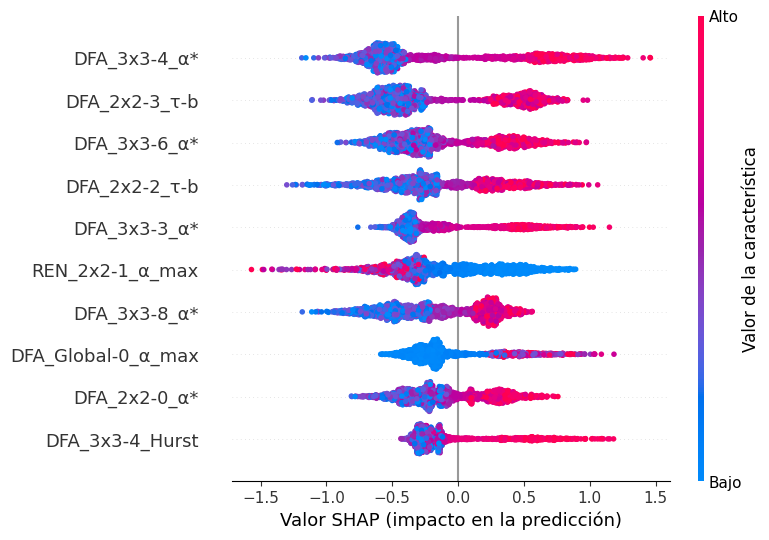

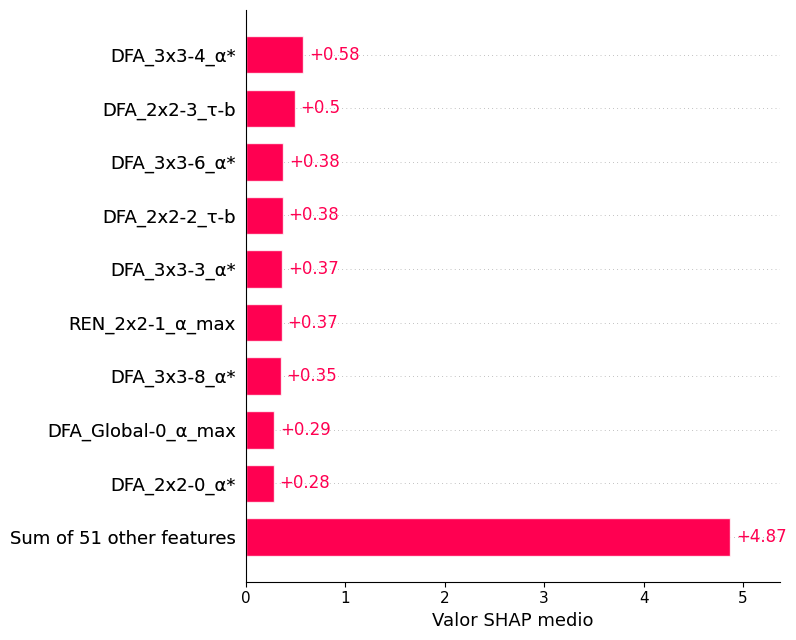

In [37]:

print(le.classes_)
# Aplicar antes de graficar SHAP
X_renamed = X.rename(columns=rename_feature)
# X_renamed = X.copy()
n_features = 10

# -------------------------------------------------------------------- #
# SHAP — usando shap_matrix out-of-fold
# -------------------------------------------------------------------- #
X_df = pd.DataFrame(X_renamed.values, columns=X_renamed.columns)  # para que shap muestre nombres

if shap_matrix.ndim == 3:
    # Multiclase
    for i, c in enumerate(le.classes_):
        print(f'\nSHAP — {c}')
        shap.summary_plot(
            shap_matrix[:, :, i],
            X_df,
            feature_names=X_df.columns,
            plot_type="dot",
            max_display=10,
            show=False
        )
else:
    # Binario
    shap.summary_plot(
        shap_matrix,
        X_df,
        feature_names=X_df.columns,
        plot_type="dot",
        max_display=n_features,
        show=False
    )

# Modificar etiquetas del colorbar
fig = plt.gcf()
# plt.subplot(1,2,1)
for ax in fig.get_axes():
    # Modificar etiqueta del colorbar
    if ax != fig.get_axes()[0]:  # el segundo eje es el colorbar
        ax.set_ylabel("Valor de la característica", fontsize=12)
        # Modificar High y Low
        ax.set_yticklabels(['Bajo' if t.get_text() == 'Low' 
                            else 'Alto' if t.get_text() == 'High' 
                            else t.get_text() 
                            for t in ax.get_yticklabels()])

plt.xlabel("Valor SHAP (impacto en la predicción)")
# plt.tight_layout()
plt.show()

# plt.subplot(1,2,2)
shap.plots.bar(
    shap.Explanation(
        values=np.abs(shap_matrix).mean(axis=0) if shap_matrix.ndim == 2
               else np.abs(shap_matrix).mean(axis=(0, 2)),
        feature_names=list(X_df.columns)
    ),
    max_display=n_features,
    show=False
)

# Reemplaza el texto en español
ax = plt.gca()
for texto in ax.get_yticklabels():
    contenido = texto.get_text()
    if contenido.startswith('Sum of') and 'other features' in contenido:
        # extrae el número de features
        import re
        match = re.search(r'Sum of (\d+) other features', contenido)
        if match:
            n = match.group(1)
            texto.set_text(f'Suma de otras {n} características')

plt.xlabel("Valor SHAP medio")
plt.tight_layout()
plt.show()